# Análisis de Calidad del Vino Tinto (Red Wine Quality Analysis)

## Introducción
Este notebook tiene como objetivo clasificar la calidad del vino tinto basándose en sus propiedades fisicoquímicas utilizando el algoritmo K-Nearest Neighbors (KNN). Se realizará un preprocesamiento de los datos, un entrenamiento de modelos KNN y una evaluación de su rendimiento, incluyendo una optimización de hiperparámetros con GridSearchCV.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

## 1. Definición de Funciones Auxiliares
En esta sección, se definen funciones que serán utilizadas más adelante para la preparación de datos y el entrenamiento del modelo. Esto incluye una función para el entrenamiento del modelo KNN con GridSearchCV y una función para transformar las calificaciones de calidad en etiquetas categóricas (baja, media, alta).

In [2]:
def knn(X_train, y_train):
    model = KNeighborsClassifier()
    n_neighbors=[3,4,5,6,7,8,9, 10, 13,18,19,20, 21,22, 23, 24, 25, 30]
    weights=['uniform', 'distance']
    penalty = ['l2','l1']
    grid = dict(n_neighbors=n_neighbors, weights=weights)
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
    grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv,
                           scoring='accuracy',error_score='raise')
    grid_result = grid_search.fit(X_train, y_train)
    return  grid_result.best_estimator_


def quality_to_label(q):
    if q <= 4:
        return 0  # low
    elif q <= 6:
        return 1  # medium
    else:
        return 2  # high

## 2. Carga de Datos
Se carga el conjunto de datos de calidad del vino tinto desde un archivo CSV. Los datos contienen diversas propiedades fisicoquímicas del vino, junto con una calificación de calidad.

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=';')

## 3. Exploración Inicial de Datos (EDA)
Antes de proceder con el modelado, es crucial entender la estructura y las características de los datos. Esta sección incluye la verificación de la distribución de la variable objetivo (`quality`), la información general del DataFrame (`info()`) y estadísticas descriptivas (`describe()`).

In [4]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 4. Ingeniería de Características (Feature Engineering)
Se crea una nueva columna llamada `label` a partir de la columna `quality` para transformar el problema de regresión en un problema de clasificación. La calidad se categoriza en 3 niveles: 'baja' (0), 'media' (1) y 'alta' (2).

In [7]:

df['label'] = df['quality'].apply(quality_to_label)

## 5. Preparación de los Datos para el Modelado
En esta etapa, se dividen los datos en características (X) y la variable objetivo (y). La variable `quality` original se elimina, ya que la nueva variable `label` será la objetivo para el modelo de clasificación.

In [8]:
X = df.drop(["label", "quality"], axis=1)
y = df["label"]

## 6. División de Datos (Entrenamiento y Prueba)
Los datos se dividen en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo en datos no vistos. Se utiliza `stratify=y` para asegurar que la proporción de las clases de la variable objetivo sea similar en ambos conjuntos.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,
                                                    stratify=y, random_state=123)

## 7. Escalado de Características
Para los algoritmos basados en la distancia, como KNN, es fundamental escalar las características para evitar que aquellas con rangos de valores más grandes dominen la distancia. Aquí se utiliza `StandardScaler`.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Entrenamiento y Evaluación del Modelo KNN (Básico)
Se entrena un modelo K-Nearest Neighbors con un número fijo de vecinos (`n_neighbors=10`) y se evalúa su rendimiento utilizando un informe de clasificación que muestra precisión, recall y f1-score por clase.

In [11]:
robot = KNeighborsClassifier(n_neighbors=10) #Entrenamiento del robot con k= 10.
robot.fit(X_train, y_train)
preds  = robot.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.84      0.99      0.91       264
           2       0.67      0.14      0.23        43

    accuracy                           0.83       320
   macro avg       0.50      0.38      0.38       320
weighted avg       0.78      0.83      0.78       320



/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 9. Optimización del Modelo KNN con GridSearchCV
Para encontrar los hiperparámetros óptimos que mejoren el rendimiento del modelo, se utiliza `GridSearchCV`. Se exploran diferentes valores de `n_neighbors` y `weights` para encontrar la mejor combinación.

In [12]:
model_knn = knn(X_train, y_train) #Entrenamiento del robot con Grid. Buscando optimizar los resultados con más iteraciones e hyperparametros que benefician al modelo. Se evidencia en los resultados.
y_pred = model_knn.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.86      0.99      0.92       264
           2       0.87      0.30      0.45        43

    accuracy                           0.86       320
   macro avg       0.58      0.43      0.46       320
weighted avg       0.83      0.86      0.82       320



/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 10. Resumen del Modelo Optimizado
Esta sección muestra los mejores parámetros encontrados por GridSearchCV y una breve conclusión sobre su impacto en el modelo.

In [13]:
model_knn


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",19
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


####El modelo robot creado y optimizado con Grid, indica que su el valor de neighbors = 19 y utlizando weights = 'distance' entrega el mejor resultado.
#####Es decir, la distancia entre los valores y la cantidad es fundamental para el modelo.



## 11. Investigación Adicional: Optimización del Parámetro 'k' y Evaluación del Modelo
En esta sección, se realizará una optimización más detallada del hiperparámetro `n_neighbors` (k) para el modelo KNN, probando un rango de valores para encontrar el que ofrece la mejor precisión. Además, se incluirán métricas de evaluación adicionales como la matriz de confusión y el informe de clasificación para el modelo con el `k` óptimo.

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Lista para almacenar los resultados de precisión
accuracy_scores = []

# Rango de valores de k a probar
k_values = range(1, 21) # De 1 a 20

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    y_pred_k = knn_model.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

# Encontrar el mejor k
best_k_index = np.argmax(accuracy_scores)
best_k = k_values[best_k_index]
print(f"El mejor valor de k encontrado es: {best_k} con una precisión de {accuracy_scores[best_k_index]:.4f}")

El mejor valor de k encontrado es: 4 con una precisión de 0.8375


### 11.1 Gráfico de Precisión vs. Valores de k

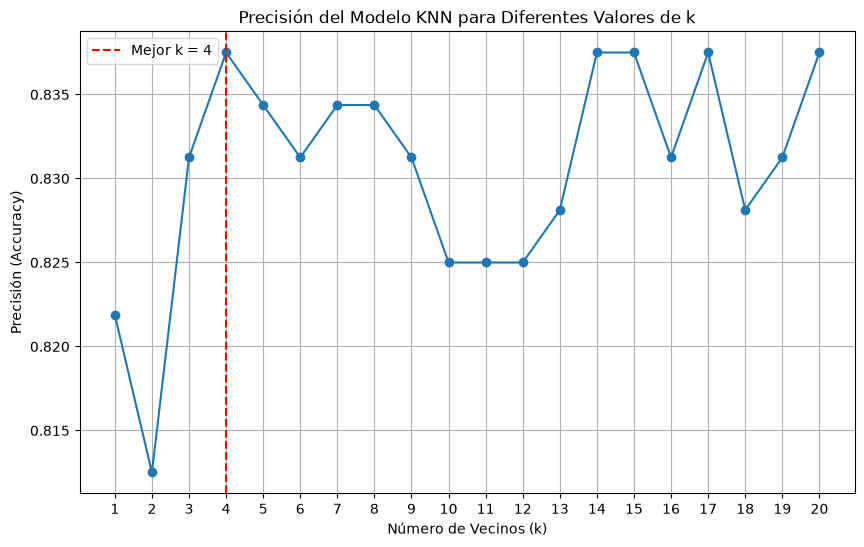

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-')
plt.title('Precisión del Modelo KNN para Diferentes Valores de k')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Precisión (Accuracy)')
plt.xticks(k_values)
plt.grid(True)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Mejor k = {best_k}')
plt.legend()
plt.show()

### 11.2 Evaluación Detallada con el Mejor 'k'

In [16]:
# Re-entrenar el modelo con el mejor k encontrado
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train)
y_pred_best_k = best_knn_model.predict(X_test_scaled)

print("\n--- Evaluación del Modelo KNN con el Mejor k ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_best_k):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_k))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_k))


--- Evaluación del Modelo KNN con el Mejor k ---
Accuracy Score: 0.8375

Confusion Matrix:
[[  1  12   0]
 [  2 254   8]
 [  0  30  13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.08      0.12        13
           1       0.86      0.96      0.91       264
           2       0.62      0.30      0.41        43

    accuracy                           0.84       320
   macro avg       0.60      0.45      0.48       320
weighted avg       0.80      0.84      0.81       320



## 12. Función de Predicción de Calidad del Vino
Esta función permite predecir la calidad de un vino individual basándose en sus propiedades fisicoquímicas, utilizando el modelo KNN previamente entrenado y optimizado.

In [17]:
def predict_wine_quality(numerical_values):
    # Convertir la lista de valores a un array de numpy y luego a DataFrame con las columnas originales
    input_array = np.array(numerical_values).reshape(1, -1)
    input_df = pd.DataFrame(input_array, columns=X.columns) # Usar las columnas originales de X

    # Escalar los valores de entrada usando el scaler entrenado
    scaled_input = scaler.transform(input_df)

    # Realizar la predicción con el modelo KNN optimizado
    prediction = best_knn_model.predict(scaled_input)

    # Mapear la predicción numérica a una etiqueta de calidad
    if prediction[0] == 0:
        quality_label = "baja 🍷"
    elif prediction[0] == 1:
        quality_label = "media 🍷🍷"
    else:
        quality_label = "alta 🍷🍷🍷"

    return f"Este vino probablemente sea de calidad {quality_label}"

### Ejemplo de Uso

In [18]:
example_values = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
print(predict_wine_quality(example_values))

Este vino probablemente sea de calidad media 🍷🍷


In [19]:
import joblib, os

os.makedirs("model", exist_ok=True)
joblib.dump(best_knn_model, "model/knn_wine_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
print("✅ Modelo guardado")

✅ Modelo guardado
